# Cookbook 1: fit one population from a VCF

This recipe creates a VCF with four pretend diploid samples and 500 segregating sites, then runs a folded analysis. The data are generated at a known selfing rate (`s = 0.60`). The goal here is just to demonstrate the workflow with a very small dataset.

In [1]:
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Create a teaching VCF

The helper below samples DGS cells from the analytical model and expands each cell into shuffled diploid genotypes to make a pretend VCF. **Real analyses begin with an existing VCF and skip this section.**

In [2]:
from selfdgs import dgs_probabilities

def simulated_vcf(path, *, sample_ids, selfing_rate, n_sites, seed):
    rng = np.random.default_rng(seed)
    probabilities = dgs_probabilities(selfing_rate, n_diploids=len(sample_ids))
    configs = list(probabilities)
    weights = np.array([probabilities[config] for config in configs])
    lines = ['##fileformat=VCFv4.2', '##contig=<ID=1>', '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">', '#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\t' + '\t'.join(sample_ids)]
    for position, index in enumerate(rng.choice(len(configs), n_sites, p=weights), start=1):
        n0, n1, n2 = configs[index]
        genotypes = ['0/0'] * n0 + ['0/1'] * n1 + ['1/1'] * n2
        rng.shuffle(genotypes)
        lines.append(f'1\t{position}\t.\tA\tG\t.\tPASS\t.\tGT\t' + '\t'.join(genotypes))
    path.write_text('\n'.join(lines) + '\n')

true_s = 0.60
sample_ids = [f'ind{i}' for i in range(1, 5)]
vcf_path = Path(tempfile.mkdtemp()) / 'teaching.vcf'
simulated_vcf(vcf_path, sample_ids=sample_ids, selfing_rate=true_s, n_sites=500, seed=17)
print(f'{len(sample_ids)} samples, 500 sites, generating s={true_s}')

4 samples, 500 sites, generating s=0.6


## Parse and inspect the DGS

We use folded polarization because an empirical VCF reference allele should not be assumed ancestral. The resulting table records how many sites have each diploid genotype configuration.

In [3]:
from selfdgs import dgs_from_vcf, dgs_to_dataframe, read_vcf_samples

samples = read_vcf_samples(vcf_path)
observed = dgs_from_vcf(vcf_path, polarization='folded')
observed_table = dgs_to_dataframe(observed).sort_values('count', ascending=False)
print(f'Parsed {sum(observed.values())} sites from {len(samples)} diploids')
observed_table.head(10)

Parsed 500 sites from 4 diploids


,n0,n1,n2,count
0,0,1,3,164
3,1,0,3,116
4,1,1,2,103
1,0,2,2,50
5,1,2,1,31
6,2,0,2,23
2,0,3,1,13


## Fit and diagnose the estimate

The likelihood is conditional on segregating sites, so the fitting function automatically excludes monomorphic cells. This notebook uses a moderate grid for speed. CLI fits use a denser default grid.

In [4]:
from selfdgs import grid_search_selfing

fit = grid_search_selfing(
    observed, n_diploids=len(samples), mode='folded',
    input_polarization='folded', s_grid=np.linspace(0, 0.98, 50),
)
pd.DataFrame([{
    'generating_s': true_s, 'estimated_s': fit.best_s,
    'support_low': fit.support_interval[0],
    'support_high': fit.support_interval[1],
    'n_fit_sites': fit.n_sites, 'boundary_optimum': fit.boundary_optimum,
    'warnings': '; '.join(fit.warnings),
}])

,generating_s,estimated_s,support_low,support_high,n_fit_sites,boundary_optimum,warnings
0,0.6,0.64,0.6,0.66,500,False,


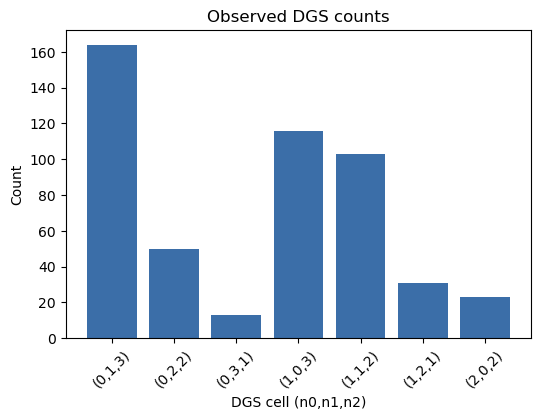

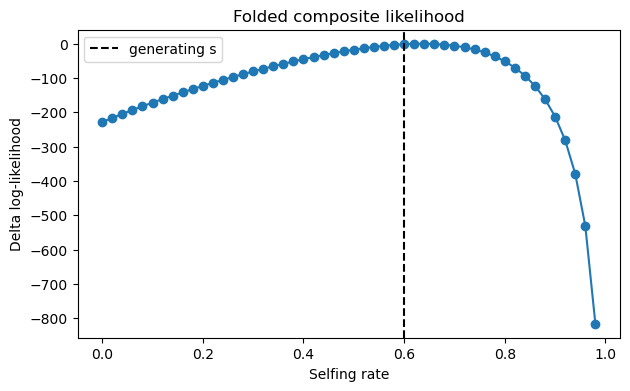

In [5]:
from selfdgs.plotting import plot_dgs_counts, plot_likelihood_curve

plot_dgs_counts(observed, title='Observed DGS counts')
plt.show()

fig = plot_likelihood_curve(fit)
fig.axes[0].axvline(true_s, color='black', linestyle='--', label='generating s')
fig.axes[0].legend()
fig.axes[0].set_title('Folded composite likelihood')
plt.show()

The estimate should be near the generating value, but finite sampling creates some variation. For empirical data, we suggest reporting the number of fitted sites, checking out warnings and the full likelihood curve, and not calling the support interval a confidence interval if there might be linkage among your sites (...you should typically expect that there will be). The CLI writes these results and the exact input/fit DGS tables automatically.